# Regression Masterclass — Pattern 2: `PyroxModule` + `pyrox_sample`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/regression_masterclass_pyrox_sample.ipynb)

Same seven Bayesian regression models as [Pattern 1 (`eqx.tree_at`)](regression_masterclass_treeat.ipynb), rewritten on top of `pyrox._core.PyroxModule`. Every weight self-registers its prior *inside* `__call__` via `self.pyrox_sample(...)`. The model function shrinks to two lines of likelihood plumbing — and the layer reuse story shines: `pyrox.nn.MCDropout` and `pyrox.nn.RBFFourierFeatures` slot in for Models 3, 6, and 7 with no glue code.

**What you'll learn:**

1. The `PyroxModule` self-registration pattern: `self.pyrox_sample(name, prior)` inside a `@pyrox_method`-decorated `__call__`.
2. How site scoping works (`pyrox_name` controls the prefix; sites become `f"{pyrox_name}.{name}"` inside the trace).
3. How the Pattern 1 model functions collapse from ~10 lines to ~3 once layers self-register.
4. How `pyrox.nn.MCDropout` and `pyrox.nn.RBFFourierFeatures` plug into a `PyroxModule` composite — one bonus: `RBFFourierFeatures` puts a prior on the spectral frequencies, so we get a richer model than Pattern 1's fixed-frequency RFF for free.

## Background — what `PyroxModule` adds on top of `eqx.Module`

Pattern 1 had a clean separation: every `numpyro.sample("w", ...)` call lived in the model function, and `eqx.tree_at` injected the result into a frozen Equinox module. This works, but the model function ends up doing a lot of bookkeeping: declare each prior, sample it, splice it into the right leaf via a (sometimes-tuple) selector, then call the module.

`pyrox._core.PyroxModule` collapses that bookkeeping by **moving the `numpyro.sample` calls into the layer itself**. Concretely:

```python
class MyLayer(PyroxModule):
    pyrox_name: str = "my_layer"          # scope for site names

    @pyrox_method                          # activates the per-call cache
    def __call__(self, x):
        w = self.pyrox_sample("w", dist.Normal(0.0, 1.0).expand([D]).to_event(1))
        b = self.pyrox_sample("b", dist.Normal(0.0, 1.0))
        return x @ w + b
```

A few things are happening:

- **`PyroxModule` *is* an `eqx.Module`**, so it stays a frozen JAX PyTree — no behaviour changes for `vmap`/`jit`/`grad`. The "weights" simply do not need to be PyTree leaves; they're random variables drawn fresh on each call.
- **`self.pyrox_sample(name, prior)` is sugar for `numpyro.sample(f"{scope}.{name}", prior)`**, where `scope = self.pyrox_name`. The `@pyrox_method` decorator activates a per-call cache so two reads of `self.pyrox_sample("w", ...)` inside one `__call__` collapse to one numpyro site.
- **`pyrox_name` controls the trace key.** With `pyrox_name="mlp"`, the weight site appears in the numpyro trace as `"mlp.w"`. Two instances of the same class need distinct names, otherwise their sites collide.
- **Composition is straightforward.** A composite `PyroxModule` whose fields are other `PyroxModule`s simply calls them; each child registers its own sites under its own `pyrox_name`.

### Pattern 1 → Pattern 2 in one diff

Pattern 1's Bayesian linear model:

```python
class LinearRegressor(eqx.Module):
    weight: jax.Array
    degree: int = eqx.field(static=True)
    def __init__(self, degree):
        self.degree = degree
        self.weight = jnp.zeros(degree + 1)
    def __call__(self, x):
        return einsum(self.features(x), self.weight, "n feat, feat -> n")

def model_linear(x, y=None, *, degree):
    net = LinearRegressor(degree=degree)
    w = numpyro.sample("w", dist.Normal(jnp.zeros(degree + 1), 1.0))
    net = eqx.tree_at(lambda m: m.weight, net, w)
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)
```

Pattern 2's version — the prior moves into `__call__`, the placeholder leaf disappears, and the model function shrinks:

```python
class LinearRegressor(PyroxModule):
    degree: int = eqx.field(static=True)
    pyrox_name: str = "lin"

    @pyrox_method
    def __call__(self, x):
        w = self.pyrox_sample(
            "w", dist.Normal(jnp.zeros(self.degree + 1), 1.0).to_event(1)
        )
        return einsum(self.features(x), w, "n feat, feat -> n")

def model_linear(x, y=None, *, net):
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)
```

The "Equinox owns architecture / NumPyro owns probability" boundary still holds — but the layer carries its own probabilistic semantics, and the model function degenerates to *just the likelihood*. That's the win.

### Inference is unchanged

`MCMC(NUTS(model_fn))`, `SVI(model_fn, AutoDelta(model_fn), ...)`, and `Predictive(model_fn, ...)` all work *exactly* as in Pattern 1. The auto-guides automatically discover the `pyrox_sample` sites (they're plain `numpyro.sample` sites under the hood, just with auto-scoped names). Every Bayesian story from the Pattern 1 [Background section](regression_masterclass_treeat.ipynb#background-from-bayesian-foundations-to-running-code) — Bayes' rule, marginal likelihood, posterior predictive integral, NUTS, ELBO — applies verbatim.

## Setup

Detect Colab and install `pyrox[colab]` (which transitively pulls in `numpyro`, `equinox`, `einops`, `matplotlib`, and `watermark`) only when running there.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from einops import einsum
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta
from numpyro.optim import Adam

from pyrox._core import PyroxModule, pyrox_method
from pyrox.nn import MCDropout, RBFFourierFeatures


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,einops,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
einops    : 0.8.2
pyrox     : 0.0.5
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Toy dataset

Identical to Pattern 1: noisy sinc, 100 training points in $[-10, 10]$, dense test grid in the same range. Same RNG seed, so the Pattern 2 fits are directly comparable to Pattern 1's.

In [4]:
key = jr.PRNGKey(666)
k_data, *k_models = jr.split(key, 16)


def latent(x):
    return jnp.sinc(x / jnp.pi)


k1, k2 = jr.split(k_data)
x_train = jr.uniform(k1, (100,), minval=-10.0, maxval=10.0)
y_train = latent(x_train) + 0.05 * jr.normal(k2, (100,))
x_test = jnp.linspace(-10.0, 10.0, 400)
y_test = latent(x_test)


def r2(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - y_true.mean()) ** 2)
    return float(1.0 - ss_res / ss_tot)


def plot_fit(ax, x_train, y_train, x_test, y_test, mean, lo=None, hi=None, title=""):
    ax.plot(x_test, y_test, "k--", lw=1.5, label="True $f(x) = \\sin(x)/x$", zorder=4)
    ax.plot(x_test, mean, "C0-", lw=2, label="Posterior mean", zorder=3)
    if lo is not None and hi is not None:
        ax.fill_between(x_test, lo, hi, color="C0", alpha=0.2, label="95% interval")
    ax.scatter(
        x_train,
        y_train,
        s=20,
        c="C1",
        edgecolors="k",
        linewidths=0.5,
        label="Training data",
        zorder=5,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend(loc="lower center", fontsize=8, ncol=2)


print(f"Training points: {x_train.shape[0]}")
print(f"Test points:     {x_test.shape[0]}")

Training points: 100
Test points:     400


## Model 1 — Bayesian linear regression

Polynomial features, Gaussian prior on the weights. The `LinearRegressor` is now a `PyroxModule` whose `__call__` declares the weight prior in line. The model function loses its `numpyro.sample("w", ...)` and `eqx.tree_at` lines — what's left is just the likelihood.

Sample sites in trace: ['f', 'lin.w', 'sigma']


Bayesian linear (degree=1) R² = -0.0171


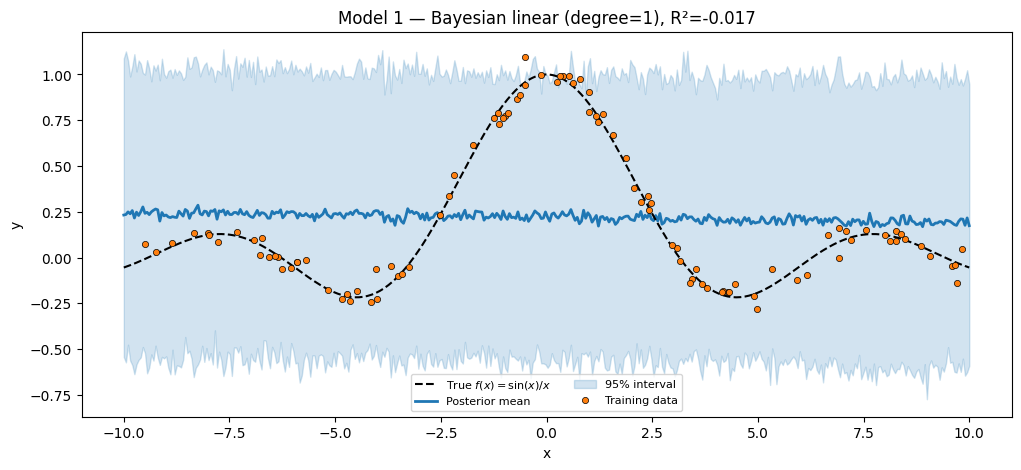

In [5]:
class LinearRegressor(PyroxModule):
    degree: int = eqx.field(static=True)
    pyrox_name: str = "lin"

    def features(self, x):
        return jnp.stack([x**p for p in range(self.degree + 1)], axis=-1)

    @pyrox_method
    def __call__(self, x):
        w = self.pyrox_sample(
            "w", dist.Normal(jnp.zeros(self.degree + 1), 1.0).to_event(1)
        )
        return einsum(self.features(x), w, "n feat, feat -> n")


def model_linear(x, y=None, *, net):
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)


net_linear = LinearRegressor(degree=1)
mcmc_linear = MCMC(
    NUTS(model_linear), num_warmup=300, num_samples=500, progress_bar=False
)
mcmc_linear.run(k_models[0], x_train, y_train, net=net_linear)
samples_linear = mcmc_linear.get_samples()
print(f"Sample sites in trace: {sorted(samples_linear)}")  # ['lin.w', 'sigma']

preds_linear = Predictive(model_linear, posterior_samples=samples_linear)(
    k_models[1], x_test, net=net_linear
)["obs"]
mean_linear = preds_linear.mean(0)
lo_linear, hi_linear = jnp.quantile(preds_linear, jnp.array([0.025, 0.975]), axis=0)
r2_linear = r2(y_test, mean_linear)

print(f"Bayesian linear (degree=1) R² = {r2_linear:.4f}")
assert r2_linear < 0.3, "Degree-1 polynomial should NOT fit sinc; R² should be near 0."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_linear,
    lo_linear,
    hi_linear,
    title=f"Model 1 — Bayesian linear (degree=1), R²={r2_linear:.3f}",
)
plt.show()

Note the trace key: `lin.w`. The `pyrox_name="lin"` field set the scope; the `name="w"` argument to `pyrox_sample` set the leaf. Multiple instances of `LinearRegressor` would need distinct `pyrox_name`s to avoid collisions.

## Models 2 & 4 — MLP, MAP and full Bayesian

A single hidden-layer MLP that self-registers four weight priors plus a sample-noise prior. *One* class — `BayesianMLP(PyroxModule)` — drives both Model 2 (MAP via `SVI` + `AutoDelta`) and Model 4 (full posterior via NUTS). The only thing that changes between the two is the inference call.

This is the cleanest demonstration of the "module owns probability, not the inference loop" principle: the same Bayesian object yields a delta posterior when paired with `AutoDelta` and a full posterior when paired with NUTS. The `prior_scale` field controls weight-prior tightness — small values regularize, large values free up the network.

In [6]:
class BayesianMLP(PyroxModule):
    hidden_dim: int = eqx.field(static=True)
    prior_scale: float = 1.0
    pyrox_name: str = "mlp"

    @pyrox_method
    def __call__(self, x):
        H = self.hidden_dim
        s = self.prior_scale
        W1 = self.pyrox_sample("W1", dist.Normal(jnp.zeros((1, H)), s).to_event(2))
        b1 = self.pyrox_sample("b1", dist.Normal(jnp.zeros(H), s).to_event(1))
        W2 = self.pyrox_sample("W2", dist.Normal(jnp.zeros((H, 1)), s).to_event(2))
        b2 = self.pyrox_sample("b2", dist.Normal(0.0, s))
        h = jnp.tanh(einsum(x, W1, "n, one h -> n h") + b1)
        return einsum(h, W2, "n h, h one -> n") + b2


def model_nnet(x, y=None, *, net):
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(1.0))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)

**Model 2 — MAP.** `AutoDelta(model_nnet)` constructs a delta guide over every sample site, including the `mlp.W1` / `mlp.b1` / etc. ones registered by `BayesianMLP`. `SVI` then maximizes the joint log-density.

MAP MLP (H=30) R² = 0.9917


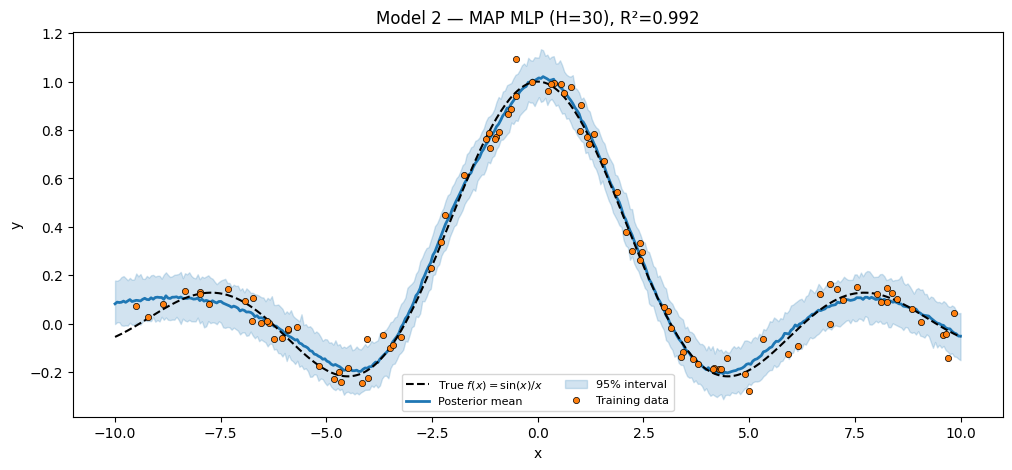

In [7]:
net_mlp_map = BayesianMLP(hidden_dim=30, pyrox_name="mlp_map")
guide_nnet = AutoDelta(model_nnet)
svi_nnet = SVI(model_nnet, guide_nnet, Adam(5e-3), Trace_ELBO())
svi_result_nnet = svi_nnet.run(
    k_models[2], 2000, x_train, y_train, net=net_mlp_map, progress_bar=False
)
preds_nnet = Predictive(
    model_nnet, params=svi_result_nnet.params, num_samples=200, guide=guide_nnet
)(k_models[3], x_test, net=net_mlp_map)["obs"]
mean_nnet = preds_nnet.mean(0)
lo_nnet, hi_nnet = jnp.quantile(preds_nnet, jnp.array([0.025, 0.975]), axis=0)
r2_nnet = r2(y_test, mean_nnet)

print(f"MAP MLP (H=30) R² = {r2_nnet:.4f}")
assert r2_nnet > 0.85, f"MAP MLP should fit sinc well; got R²={r2_nnet:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_nnet,
    lo_nnet,
    hi_nnet,
    title=f"Model 2 — MAP MLP (H=30), R²={r2_nnet:.3f}",
)
plt.show()

**Model 4 — full Bayesian via NUTS.** Same module, fresh instance with a smaller hidden dim (NUTS over a hundred-parameter MLP is the limit of what mixes well in a few seconds). The inference call is the only difference from Model 2.

Bayesian MLP via NUTS (H=15) R² = 0.9945


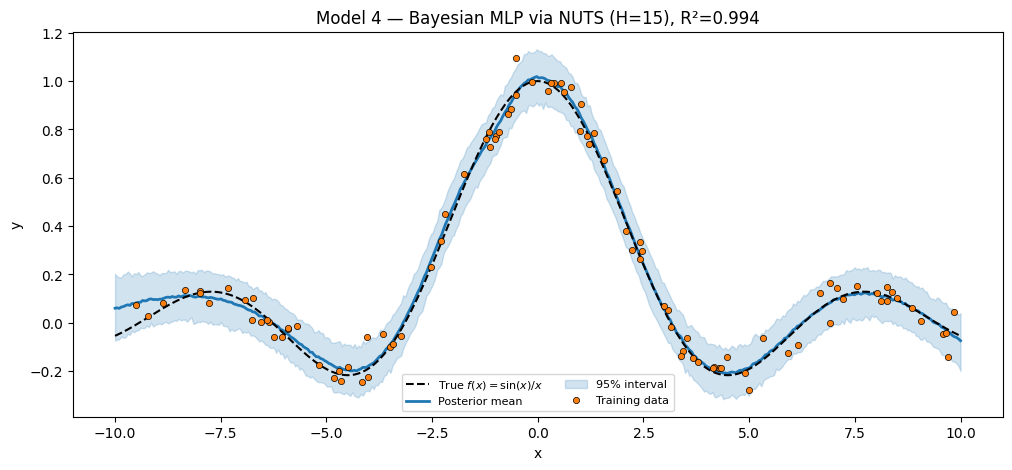

In [8]:
net_mlp_nuts = BayesianMLP(hidden_dim=15, prior_scale=1.0, pyrox_name="mlp_nuts")
mcmc_bnnet = MCMC(NUTS(model_nnet), num_warmup=300, num_samples=500, progress_bar=False)
mcmc_bnnet.run(k_models[6], x_train, y_train, net=net_mlp_nuts)
samples_bnnet = mcmc_bnnet.get_samples()
preds_bnnet = Predictive(model_nnet, posterior_samples=samples_bnnet)(
    k_models[7], x_test, net=net_mlp_nuts
)["obs"]
mean_bnnet = preds_bnnet.mean(0)
lo_bnnet, hi_bnnet = jnp.quantile(preds_bnnet, jnp.array([0.025, 0.975]), axis=0)
r2_bnnet = r2(y_test, mean_bnnet)

print(f"Bayesian MLP via NUTS (H=15) R² = {r2_bnnet:.4f}")
assert r2_bnnet > 0.70, f"Bayesian MLP via NUTS should fit sinc; got R²={r2_bnnet:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_bnnet,
    lo_bnnet,
    hi_bnnet,
    title=f"Model 4 — Bayesian MLP via NUTS (H=15), R²={r2_bnnet:.3f}",
)
plt.show()

Two `BayesianMLP` instances with distinct `pyrox_name`s coexist in the trace because their site keys are namespaced (`mlp_map.W1` vs `mlp_nuts.W1`). Reuse without surgery.

## Model 3 — MC-Dropout MLP via `pyrox.nn.MCDropout`

Pattern 1 had to write its own dropout layer that called `numpyro.prng_key()` inside the model function. Pattern 2 reuses [`pyrox.nn.MCDropout`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/nn/_layers.py) directly — it is a plain `eqx.Module` that takes an explicit `key` argument, and our `BayesianMLPDropout` pulls a fresh key per trace via `numpyro.prng_key()`. Composition is the only new code.

**Generative model** (same as Pattern 1):

$$z_{ij} \sim \text{Bernoulli}(1 - p_{\text{drop}}), \qquad \tilde h_i = h_i \odot z_i / (1 - p_{\text{drop}}), \qquad y_i \sim \mathcal{N}(\tilde h_i W_2 + b_2,\, \sigma^2).$$

MC-Dropout MLP (H=30, p=0.1) R² = 0.9081


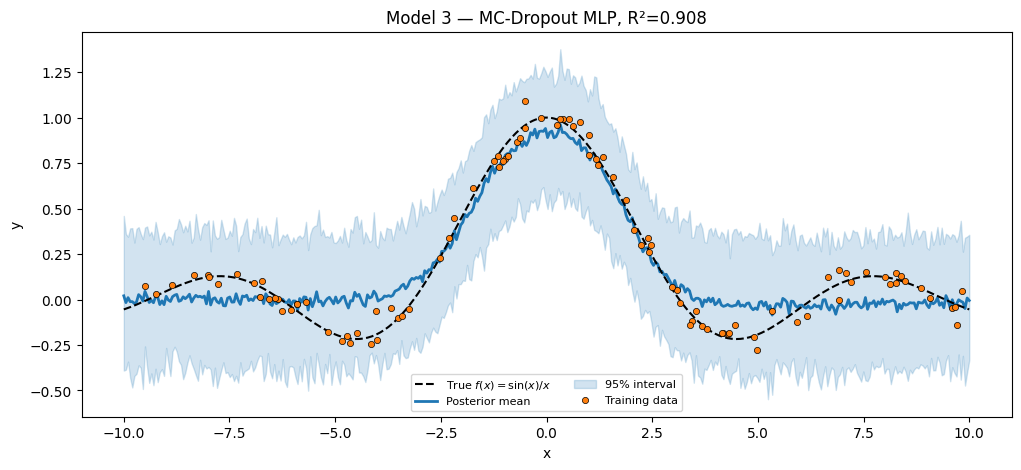

In [9]:
class BayesianMLPDropout(PyroxModule):
    hidden_dim: int = eqx.field(static=True)
    dropout: MCDropout  # plain eqx.Module — takes (x, key=...)
    pyrox_name: str = "mlpd"

    @pyrox_method
    def __call__(self, x):
        H = self.hidden_dim
        W1 = self.pyrox_sample("W1", dist.Normal(jnp.zeros((1, H)), 1.0).to_event(2))
        b1 = self.pyrox_sample("b1", dist.Normal(jnp.zeros(H), 1.0).to_event(1))
        W2 = self.pyrox_sample("W2", dist.Normal(jnp.zeros((H, 1)), 1.0).to_event(2))
        b2 = self.pyrox_sample("b2", dist.Normal(0.0, 1.0))
        h = jnp.tanh(einsum(x, W1, "n, one h -> n h") + b1)
        # numpyro.prng_key() is fresh per trace — different mask per SVI step
        # AND per Predictive draw. No discrete latent in the trace, no funsor.
        h = self.dropout(h, key=numpyro.prng_key())
        return einsum(h, W2, "n h, h one -> n") + b2


net_dropout = BayesianMLPDropout(hidden_dim=30, dropout=MCDropout(rate=0.1))
guide_dropout = AutoDelta(model_nnet)
svi_dropout = SVI(model_nnet, guide_dropout, Adam(5e-3), Trace_ELBO())
svi_result_dropout = svi_dropout.run(
    k_models[4], 2000, x_train, y_train, net=net_dropout, progress_bar=False
)
preds_dropout = Predictive(
    model_nnet,
    params=svi_result_dropout.params,
    num_samples=100,
    guide=guide_dropout,
)(k_models[5], x_test, net=net_dropout)["obs"]
mean_dropout = preds_dropout.mean(0)
lo_dropout, hi_dropout = jnp.quantile(preds_dropout, jnp.array([0.025, 0.975]), axis=0)
r2_dropout = r2(y_test, mean_dropout)

print(f"MC-Dropout MLP (H=30, p=0.1) R² = {r2_dropout:.4f}")
assert r2_dropout > 0.80, f"MC-Dropout should fit sinc; got R²={r2_dropout:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_dropout,
    lo_dropout,
    hi_dropout,
    title=f"Model 3 — MC-Dropout MLP, R²={r2_dropout:.3f}",
)
plt.show()

`pyrox.nn.MCDropout` *is not* a `PyroxModule` — it's a plain `eqx.Module` with a `key` kwarg, because dropout's randomness has nothing to do with priors. Drawing the key from `numpyro.prng_key()` plugs it into the trace machinery without making the mask itself a sample site.

## Model 5 — SVR via Random Fourier Features (fresh `PyroxModule`)

A from-scratch RFF feature map with **fixed** spectral frequencies (matching Pattern 1), wrapped as a `PyroxModule`. Only the linear weights are sampled; the frequencies $\omega$ and phases $b$ are deterministic constants stored as `jax.Array` fields.

SVR via fixed RFF (D=40) R² = 0.9957


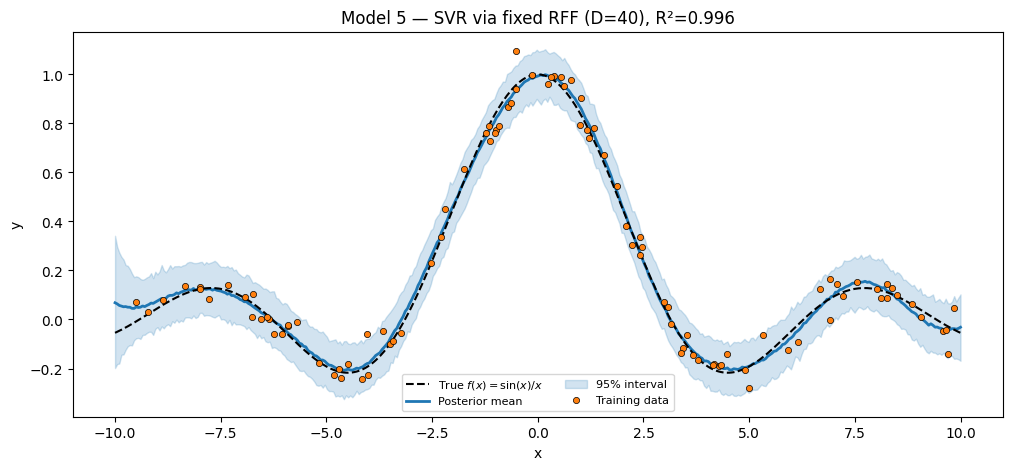

In [10]:
class FixedRFF(PyroxModule):
    omega: jax.Array
    bias: jax.Array
    n_features: int = eqx.field(static=True)
    pyrox_name: str = "rff"

    @classmethod
    def init(cls, n_features, lengthscale, *, key, name="rff"):
        k1, k2 = jr.split(key)
        omega = jr.normal(k1, (n_features,)) / lengthscale
        bias = jr.uniform(k2, (n_features,), minval=0.0, maxval=2.0 * jnp.pi)
        return cls(omega=omega, bias=bias, n_features=n_features, pyrox_name=name)

    @pyrox_method
    def __call__(self, x):
        proj = einsum(x, self.omega, "n, d -> n d")
        Phi = jnp.sqrt(2.0 / self.n_features) * jnp.cos(proj + self.bias)
        w = self.pyrox_sample(
            "w", dist.Normal(jnp.zeros(self.n_features), 1.0).to_event(1)
        )
        return einsum(Phi, w, "n d, d -> n")


net_svr = FixedRFF.init(n_features=40, lengthscale=1.0, key=k_models[8], name="svr_rff")
mcmc_svr = MCMC(NUTS(model_linear), num_warmup=300, num_samples=500, progress_bar=False)
mcmc_svr.run(k_models[9], x_train, y_train, net=net_svr)
samples_svr = mcmc_svr.get_samples()
preds_svr = Predictive(model_linear, posterior_samples=samples_svr)(
    k_models[10], x_test, net=net_svr
)["obs"]
mean_svr = preds_svr.mean(0)
lo_svr, hi_svr = jnp.quantile(preds_svr, jnp.array([0.025, 0.975]), axis=0)
r2_svr = r2(y_test, mean_svr)

print(f"SVR via fixed RFF (D=40) R² = {r2_svr:.4f}")
assert r2_svr > 0.80, f"SVR via RFF should fit sinc well; got R²={r2_svr:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_svr,
    lo_svr,
    hi_svr,
    title=f"Model 5 — SVR via fixed RFF (D=40), R²={r2_svr:.3f}",
)
plt.show()

Notice the model function is the same `model_linear` we wrote for Model 1: any `PyroxModule` whose `__call__` returns a `(N,)` mean fits this generic likelihood-only template. That is the boilerplate-collapse story made concrete.

## Model 6 — Approximate GP via [`pyrox.nn.RBFFourierFeatures`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/nn/_layers.py)

Time to lean on the package. [`pyrox.nn.RBFFourierFeatures`](https://github.com/jejjohnson/pyrox/blob/main/src/pyrox/nn/_layers.py) is a `PyroxModule` whose `__call__` self-registers two priors:

- $W \sim \mathcal{N}(0, I)$ for the spectral frequencies (this is the RBF spectral density),
- $\ell \sim \text{LogNormal}(\log \ell_0, 1)$ for the lengthscale.

So our Pattern 2 Model 6 is *richer* than Pattern 1's: where Pattern 1 fixed both $\omega$ and $\ell$, this version learns posteriors over both, alongside the amplitude and linear weights. We add the amplitude prior + linear weights in our composite, and the package layer handles everything underneath.

**Output shape note.** `RBFFourierFeatures` returns the concatenated $[\cos(xW/\ell), \sin(xW/\ell)]$ basis with $2 \times \texttt{n\_features}$ columns, so the linear weight vector has length $2 \times \texttt{n\_features}$.

Approx GP via packaged RFF R² = 0.9978
Sample sites in trace: ['f', 'gp_rff.amplitude', 'gp_rff.rff.W', 'gp_rff.rff.lengthscale', 'gp_rff.w', 'sigma']


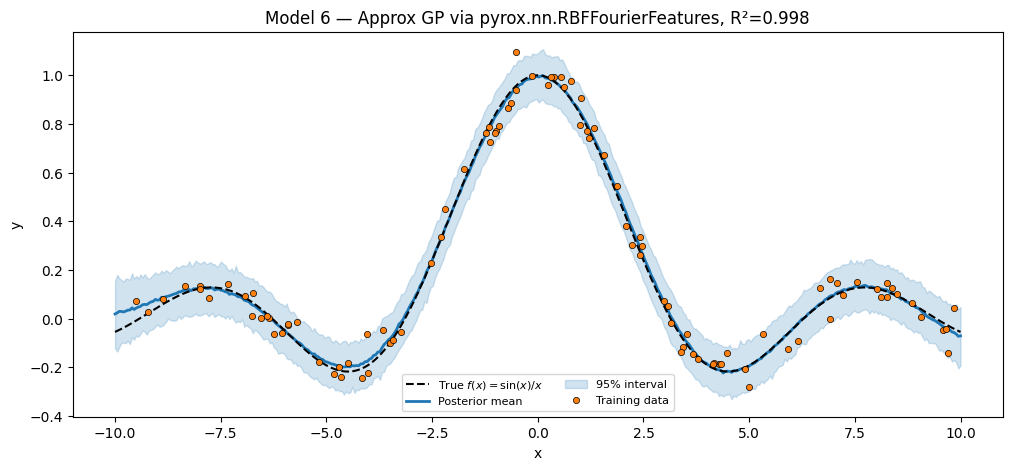

In [11]:
class GPviaPackagedRFF(PyroxModule):
    rff: RBFFourierFeatures  # learns W and lengthscale as priors
    pyrox_name: str = "gp_rff"

    @pyrox_method
    def __call__(self, x):
        Phi = self.rff(x.reshape(-1, 1))  # (N, 2 * n_features)
        D = Phi.shape[-1]
        amplitude = self.pyrox_sample("amplitude", dist.HalfNormal(1.0))
        w = self.pyrox_sample("w", dist.Normal(jnp.zeros(D), amplitude).to_event(1))
        return einsum(Phi, w, "n d, d -> n")


def model_gp(x, y=None, *, net):
    f = numpyro.deterministic("f", net(x))
    sigma = numpyro.sample("sigma", dist.HalfNormal(0.1))
    numpyro.sample("obs", dist.Normal(f, sigma), obs=y)


rff_gp = RBFFourierFeatures(
    in_features=1, n_features=20, init_lengthscale=1.0, pyrox_name="gp_rff.rff"
)
net_gp = GPviaPackagedRFF(rff=rff_gp)
mcmc_gp = MCMC(NUTS(model_gp), num_warmup=300, num_samples=500, progress_bar=False)
mcmc_gp.run(k_models[11], x_train, y_train, net=net_gp)
samples_gp = mcmc_gp.get_samples()
preds_gp = Predictive(model_gp, posterior_samples=samples_gp)(
    k_models[12], x_test, net=net_gp
)["obs"]
mean_gp = preds_gp.mean(0)
lo_gp, hi_gp = jnp.quantile(preds_gp, jnp.array([0.025, 0.975]), axis=0)
r2_gp = r2(y_test, mean_gp)

print(f"Approx GP via packaged RFF R² = {r2_gp:.4f}")
print(f"Sample sites in trace: {sorted(samples_gp)}")
assert r2_gp > 0.80, f"Approx-GP via packaged RFF should fit sinc; got R²={r2_gp:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_gp,
    lo_gp,
    hi_gp,
    title=f"Model 6 — Approx GP via pyrox.nn.RBFFourierFeatures, R²={r2_gp:.3f}",
)
plt.show()

Inspect the trace keys printed above: `gp_rff.rff.W`, `gp_rff.rff.lengthscale`, `gp_rff.amplitude`, `gp_rff.w`, `sigma`. The dotted scoping comes from the nested `pyrox_name`s — the inner layer's `pyrox_name="gp_rff.rff"` includes the outer scope as a prefix because we set it that way at construction. (Nothing magical: it's just a string.)

## Model 7 — Deep GP via two stacked `pyrox.nn.RBFFourierFeatures`

Same Cutajar et al. (2017) deep-RFF architecture as Pattern 1, but now both RFF layers are package classes that learn their own $W$ and $\ell$. The inter-layer linear map $W_1$ and the output linear weights $w_2$ are this composite's own `pyrox_sample` sites.

**Implementation note.** Pattern 1's deep model called `rff2` inside a Python `for j in range(inner_dim):` loop — fine when `rff2` had no priors. With the packaged `RBFFourierFeatures` that *does* sample sites, calling it $\text{inner\_dim}$ times in a loop would register the same site name $\text{inner\_dim}$ times and crash. The fix is to call `rff2` **once** with a batched input of shape `(N, inner_dim, 1)`, then mean-reduce over the `inner_dim` axis:

Deep GP via stacked packaged RFF R² = 0.9978


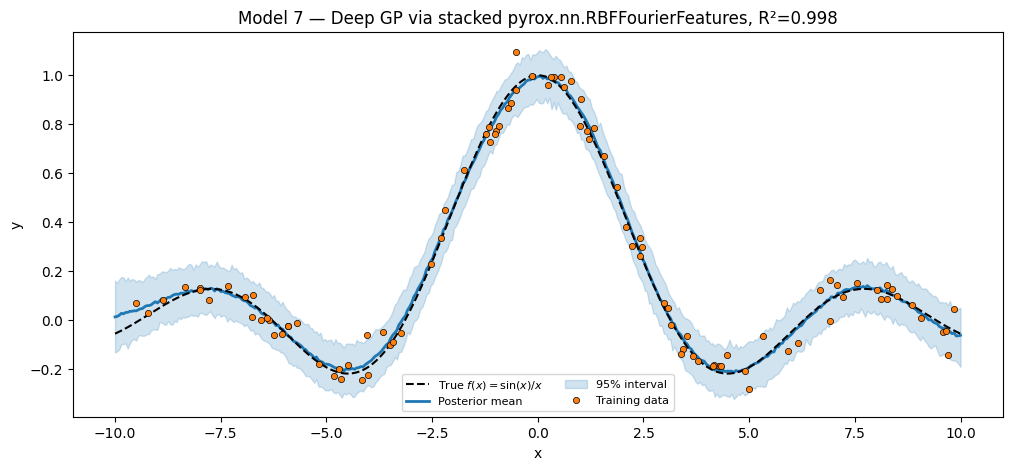

In [12]:
class DeepGPviaPackagedRFF(PyroxModule):
    rff1: RBFFourierFeatures
    rff2: RBFFourierFeatures
    inner_dim: int = eqx.field(static=True)
    pyrox_name: str = "deep"

    @pyrox_method
    def __call__(self, x):
        # Layer 1: scalar input -> (N, 2*D1) -> linear map W1 -> (N, inner_dim)
        Phi1 = self.rff1(x.reshape(-1, 1))
        D1 = Phi1.shape[-1]
        W1 = self.pyrox_sample(
            "W1", dist.Normal(jnp.zeros((D1, self.inner_dim)), 1.0).to_event(2)
        )
        h = einsum(Phi1, W1, "n d1, d1 inner -> n inner")
        # Layer 2: rff2 takes (*batch, D_in=1). Broadcast h to (N, inner_dim, 1)
        # and call rff2 ONCE, then mean over inner_dim — no Python loop, no
        # site-name collision.
        Phi2 = self.rff2(h[..., None]).mean(axis=1)  # (N, 2*D2)
        D2 = Phi2.shape[-1]
        w2 = self.pyrox_sample("w2", dist.Normal(jnp.zeros(D2), 1.0).to_event(1))
        return einsum(Phi2, w2, "n d2, d2 -> n")


rff1 = RBFFourierFeatures(
    in_features=1, n_features=8, init_lengthscale=1.0, pyrox_name="deep.rff1"
)
rff2 = RBFFourierFeatures(
    in_features=1, n_features=5, init_lengthscale=1.0, pyrox_name="deep.rff2"
)
net_deep = DeepGPviaPackagedRFF(rff1=rff1, rff2=rff2, inner_dim=4)
mcmc_deep = MCMC(NUTS(model_gp), num_warmup=200, num_samples=300, progress_bar=False)
mcmc_deep.run(k_models[13], x_train, y_train, net=net_deep)
samples_deep = mcmc_deep.get_samples()
preds_deep = Predictive(model_gp, posterior_samples=samples_deep)(
    k_models[14], x_test, net=net_deep
)["obs"]
mean_deep = preds_deep.mean(0)
lo_deep, hi_deep = jnp.quantile(preds_deep, jnp.array([0.025, 0.975]), axis=0)
r2_deep = r2(y_test, mean_deep)

print(f"Deep GP via stacked packaged RFF R² = {r2_deep:.4f}")
assert r2_deep > 0.70, f"Deep RFF should fit sinc; got R²={r2_deep:.3f}."

fig, ax = plt.subplots(figsize=(12, 5))
plot_fit(
    ax,
    x_train,
    y_train,
    x_test,
    y_test,
    mean_deep,
    lo_deep,
    hi_deep,
    title=f"Model 7 — Deep GP via stacked pyrox.nn.RBFFourierFeatures, "
    f"R²={r2_deep:.3f}",
)
plt.show()

## Side-by-side summary

All seven models. The 1×3 panel below stacks three representative posteriors so the qualitative shape of the predictive bands is visible.

Model                                      Inference        R²
--------------------------------------------------------------
1. Bayesian linear (degree=1)              NUTS         -0.017
2. MAP MLP                                 SVI+Delta     0.992
3. MC-Dropout MLP (MCDropout)              SVI+Delta     0.908
4. Bayesian MLP                            NUTS          0.994
5. SVR via fixed RFF (D=40)                NUTS          0.996
6. Approx GP (RBFFourierFeatures)          NUTS          0.998
7. Deep GP (stacked RBFFourierFeatures)    NUTS          0.998


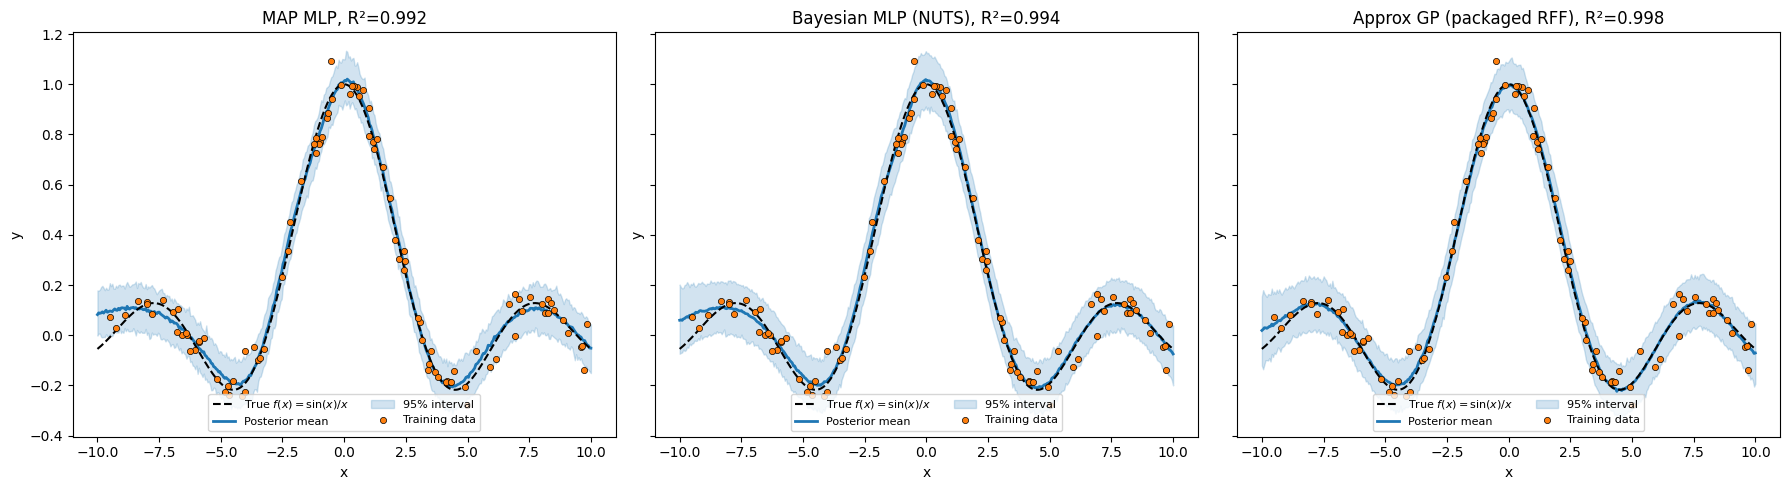

In [13]:
print(f"{'Model':<42} {'Inference':<11} {'R²':>7}")
print("-" * 62)
print(f"{'1. Bayesian linear (degree=1)':<42} {'NUTS':<11} {r2_linear:>7.3f}")
print(f"{'2. MAP MLP':<42} {'SVI+Delta':<11} {r2_nnet:>7.3f}")
print(f"{'3. MC-Dropout MLP (MCDropout)':<42} {'SVI+Delta':<11} {r2_dropout:>7.3f}")
print(f"{'4. Bayesian MLP':<42} {'NUTS':<11} {r2_bnnet:>7.3f}")
print(f"{'5. SVR via fixed RFF (D=40)':<42} {'NUTS':<11} {r2_svr:>7.3f}")
print(f"{'6. Approx GP (RBFFourierFeatures)':<42} {'NUTS':<11} {r2_gp:>7.3f}")
print(f"{'7. Deep GP (stacked RBFFourierFeatures)':<42} {'NUTS':<11} {r2_deep:>7.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plot_fit(
    axes[0],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_nnet,
    lo_nnet,
    hi_nnet,
    title=f"MAP MLP, R²={r2_nnet:.3f}",
)
plot_fit(
    axes[1],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_bnnet,
    lo_bnnet,
    hi_bnnet,
    title=f"Bayesian MLP (NUTS), R²={r2_bnnet:.3f}",
)
plot_fit(
    axes[2],
    x_train,
    y_train,
    x_test,
    y_test,
    mean_gp,
    lo_gp,
    hi_gp,
    title=f"Approx GP (packaged RFF), R²={r2_gp:.3f}",
)
plt.tight_layout()
plt.show()

## Pattern 1 vs Pattern 2 — what changed

| Aspect | Pattern 1 (`tree_at`) | Pattern 2 (`PyroxModule`) |
|---|---|---|
| Where priors live | In the model function as `numpyro.sample` calls | Inside `__call__` as `self.pyrox_sample` calls |
| Bridge into the module | `eqx.tree_at(selector, net, w)` | None — the layer *is* the trace site |
| Model function size | ~10 lines per model | ~3 lines (just the likelihood) |
| Layer reusability | Define a fresh `eqx.Module` each time | Same `BayesianMLP` instance (with a unique `pyrox_name`) drives MAP + NUTS |
| Reuse of `pyrox.nn` | None | `MCDropout`, `RBFFourierFeatures` slot in via composition |
| Site naming | Flat (`"W1"`, `"w"`, ...) | Scoped (`"mlp.W1"`, `"gp_rff.rff.W"`, ...) |

Inference machinery is unchanged: `MCMC(NUTS(model_fn))`, `SVI(...)`, `Predictive(...)` work identically against both patterns.

## What's next

- **Pattern 3 — `Parameterized` + `PyroxParam`.** Constraints, priors, and autoguide selection become declarative class fields registered in `setup()`. Models 6–7 swap their RFF approximations for the actual exact-GP primitives (`pyrox.gp.GPPrior` + `ConditionedGP`) — that's where the abstraction *replaces* the workaround. See [`regression_masterclass_parameterized.ipynb`](regression_masterclass_parameterized.ipynb) once it lands.